In [1]:
# Standard library
from pathlib import Path
import sys

# Make the src package importable
project_root = Path.cwd().parent

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

# Third-party libraries
import pandas as pd
from sqlalchemy import text
from sqlalchemy.types import Integer, NVARCHAR, DECIMAL

# Local package
from src.database import get_engine

# Create database connection
engine = get_engine()

print("✅ Connected successfully!")

✅ Connected successfully!


In [10]:
# Force Pandas to display floating-point numbers normally instead of in scientific notation
pd.options.display.float_format = '{:.2f}'.format

In [11]:
# 1. Extract Data from Silver Layer
print("Reading data from Silver layer...")
df_internet = pd.read_sql(
    "SELECT OrderDate, SalesAmount, TotalProductCost FROM silver.FactInternetSales",con=engine
)
df_reseller = pd.read_sql(
    "SELECT OrderDate,  SalesAmount, TotalProductCost FROM silver.FactResellerSales",con=engine
)

# 2. Transform: Standardize Dates and Combine Channels
print("Standardizing temporal markers...")
df_internet['Channel'] = 'Internet'
df_reseller['Channel'] = 'Reseller'

# Combine channels
df_time_sales = pd.concat([df_internet, df_reseller],ignore_index=True)

# Convert OrderDate to datetime and extract Year, Month, and YearMonth tokens
df_time_sales['OrderDate'] = pd.to_datetime(df_time_sales['OrderDate'])
df_time_sales['CalendarYear'] = df_time_sales['OrderDate'].dt.year
df_time_sales['MonthNumberOfYear'] = df_time_sales['OrderDate'].dt.month
# Format Year-Month for clean chronological sorting (e.g., "2013-01")
df_time_sales['CalendarMonth'] = df_time_sales['OrderDate'].dt.to_period('M').astype(str)

print("Aggregating growth metrics over time...")
# 3. Group by Year, Month, and Channel to aggregate financial statistics
gold_sales_perf = df_time_sales.groupby(['CalendarYear', 'MonthNumberOfYear', 'CalendarMonth', 'Channel']).agg(
    MonthlyRevenue=('SalesAmount', 'sum'),
    MonthlyCost=('TotalProductCost', 'sum')
).reset_index()

# 4. Calculate Profit margins per time bracket
gold_sales_perf['MonthlyProfit'] = gold_sales_perf['MonthlyRevenue'] - gold_sales_perf['MonthlyCost']

# Display a preview of your chronological sales matrix
gold_sales_perf.sort_values(by=['CalendarYear', 'MonthNumberOfYear']).head()

Reading data from Silver layer...
Standardizing temporal markers...
Aggregating growth metrics over time...


,CalendarYear,MonthNumberOfYear,CalendarMonth,Channel,MonthlyRevenue,MonthlyCost,MonthlyProfit
0,2010,12,2010-12,Internet,28943.70,17251.16,11692.54
1,2011,1,2011-01,Internet,469823.91,280872.74,188951.18
2,2011,1,2011-01,Reseller,1538408.31,1469459.58,68948.73
3,2011,2,2011-02,Internet,466334.90,278294.99,188039.91
4,2011,3,2011-03,Internet,485198.66,292121.42,193077.24


In [12]:
print("writing processed data gold to gold.FactSalesPerformance...")

# Build a performance-optimized data schema
sales_perf_dtypes = {
    'CalendarYear': Integer(),
    'MonthNumberOfYear': Integer(),
    'CalendarMonth': NVARCHAR(7),      # Standardized string size for "YYYY-MM"
    'Channel': NVARCHAR(20),
    'MonthlyRevenue': DECIMAL(18, 2),
    'MonthlyCost': DECIMAL(18, 2),
    'MonthlyProfit': DECIMAL(18, 2)
}

gold_sales_perf.to_sql(
    name='FactSalesPerformance', 
    con=engine, 
    schema='gold', 
    if_exists='replace',
    index=False,
    dtype=sales_perf_dtypes
)

print("🎉 gold.FactSalesPerformance successfully loaded!")



writing processed data gold to gold.FactSalesPerformance...
🎉 gold.FactSalesPerformance successfully loaded!


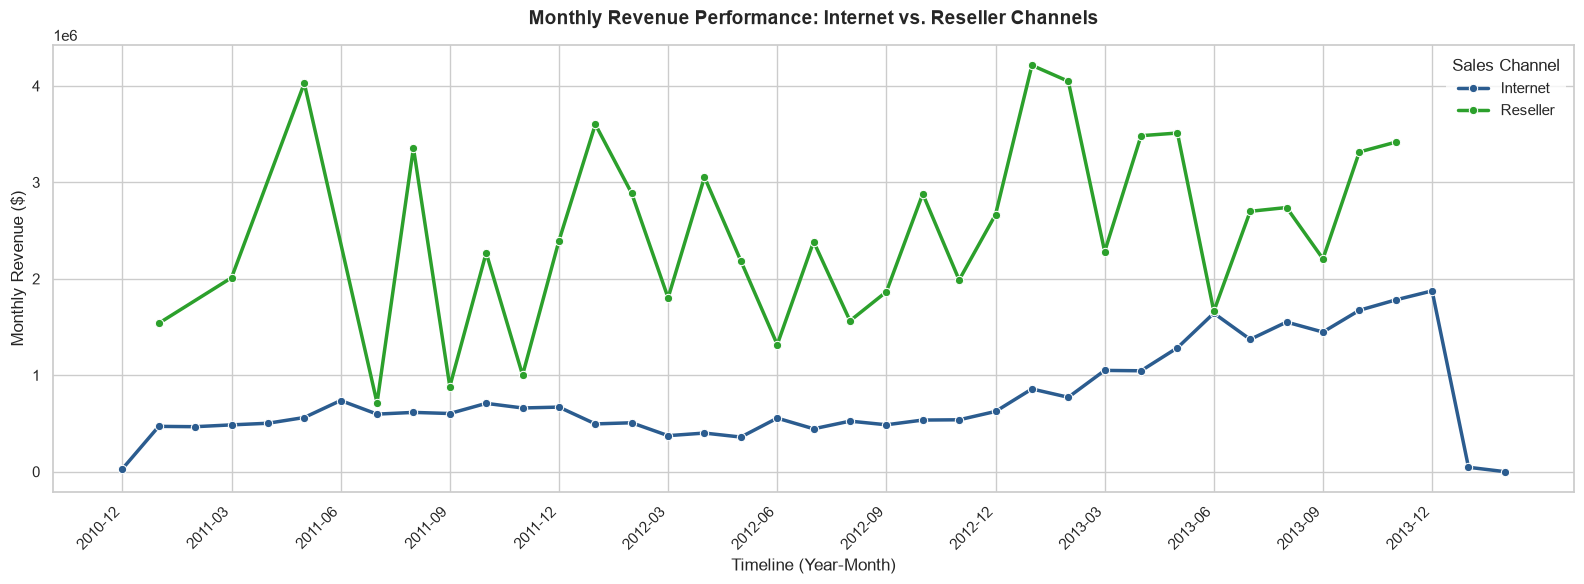

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure the data is sorted chronologically for line plotting
gold_sales_perf_sorted = gold_sales_perf.sort_values(by=['CalendarYear', 'MonthNumberOfYear'])

# Set clean style and chart size
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [16, 6]

# Create the line chart
ax = sns.lineplot(
    data=gold_sales_perf_sorted,
    x='CalendarMonth',
    y='MonthlyRevenue',
    hue='Channel',
    marker='o',
    linewidth=2.5,
    palette=['#2b5c8f', '#2ca02c']  # Clean blue for Internet, professional green for Reseller
)

# Clean up the X-axis labels so they don't overlap
# This keeps only every 3rd month label visible if the timeline is long
ticks = ax.get_xticks()
labels = [gold_sales_perf_sorted['CalendarMonth'].unique()[i] for i in range(len(gold_sales_perf_sorted['CalendarMonth'].unique()))]
ax.set_xticks(ticks[::3])
ax.set_xticklabels(labels[::3], rotation=45, ha='right')

# Titles and Labels
plt.title('Monthly Revenue Performance: Internet vs. Reseller Channels', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Timeline (Year-Month)', fontsize=12)
plt.ylabel('Monthly Revenue ($)', fontsize=12)
plt.legend(title='Sales Channel', frameon=True, facecolor='white', edgecolor='none')

# Adjust layout and display
plt.tight_layout()
plt.show()